## A notebook to analyze groups of trackarrays  

### Read in, combine, and making measurements 

In [1]:
import croparray as ca
from pathlib import Path

In [2]:
# ============================
# USER-DEFINED PARAMETERS
# ============================

# Files & Directories
DATA_DIR_1 = Path(r"Z:\SharedInternal\Marianas_data\20260409\wt_U2OS_KDM5B\Stacks\CropArrays")
DATA_DIR_2 = Path(r"Z:\SharedInternal\Marianas_data\20260409\dZNF_KDM5B\Stacks\CropArrays")
DATA_DIR_3 = Path(r"Z:\SharedInternal\Marianas_data\20260409\wt_U2OS_SA\Stacks\CropArrays")
DATA_DIR_4 = Path(r"Z:\SharedInternal\Marianas_data\20260409\dZNF_SA\Stacks\CropArrays")
OUTPUT = Path(r"\\129.82.125.64\TSnas2\SharedInternal\RiboJamProject\20260409_deltaZNF")

nc_files_1 = sorted(DATA_DIR_1.glob("*.nc"))
nc_files_2 = sorted(DATA_DIR_2.glob("*.nc"))
nc_files_3 = sorted(DATA_DIR_3.glob("*.nc"))
nc_files_4 = sorted(DATA_DIR_4.glob("*.nc"))

# Nested grouping: outer list = rna, inner list = znf
# GROUPS[rna][znf] -> list of .nc files for that condition
GROUPS = [
    [nc_files_1, nc_files_2],  # KDM5B:         +ZNF598, -ZNF598
    [nc_files_3, nc_files_4],  # KDM5B-XBP1SA:  +ZNF598, -ZNF598
]
DIMS = ["rna", "exp", "fov"]  # dims added during concatenation (outermost to innermost)
LABELS = [["KDM5B", "KDM5B-XBP1SA"], ["+ZNF598", "-ZNF598"], None]  # None = auto-label fovs by filename #

# Measurement parameters
REF_CH = 0  # Channel used to pick best z plane (only used when z was not tracked)
DISK_R = 7  # Radius of signal disk in pixels
DISK_BG = 9 # Radius of background ring in pixels (1 px thick)
ROLL_N = 1  # Rolling z-average window for signal measurement

In [3]:
### Note this will drop the 'int' layer. Can use drop_vars=None to avoid
my_ta = ca.build.open_measure_concat(
    groups=GROUPS,
    dims=DIMS,
    labels=LABELS,
    measure_kwargs=dict(ref_ch=REF_CH, disk_r=DISK_R, disk_bg=DISK_BG, roll_n=ROLL_N, 
                        use_zc=False, # if tracking done in 3D, set to True
                        drop_int=True # drop full z-stack to save memory, keeping best_z_proj 
    ),
    open_as="trackarray",  ## can be "croparray" or "trackarray"
    join="outer",
)

In [4]:
# # Need to remove this bit as unecessary if built properly
# my_ca['track_id']=my_ca['id'] # New croparrays need track_id to become trackarrays
# my_ta = ca.track_array(my_ca, as_object=True)
my_ta

TrackArray(tracks=156, t=2)

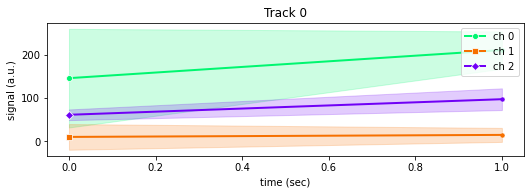

In [5]:
my_ta.isel(exp=0, fov=0).tplot.plot_track_signal_traces(track_ids=[0]);

In [6]:
# Create binary masks from "best_z" so can measure morphological properties. 
my_ta.ops.apply(
    ca.tools.binarize_crop_manual,
    channels=[0],               # Channel used to generate mask
    source="best_z",            # Image layer to threshold (typically z-projected signal)
    out_name="ch{ch}_mask",     # Output mask variable name (→ "ch0_mask")

    # Recommended parameters forwarded directly to binarize_crop_manual(...)
    func_kwargs=dict(
        q=0.45,                 # Threshold at 45% after intensity normalization
        q_range=(0.02, 0.999),  # Normalize intensities using 2%–99.9% quantile range
        q_positive_only=True,   # Ignore negative pixels (important for best_z)
        close_px=1,             # Morphological closing (bridge small gaps)
        smooth_px=0,            # Light smoothing of mask edges
        fill_holes=False,       # Do not fill internal holes
        return_uint8=True,      # Store mask as uint8 (0/1)
        morph_px=0,             # Apply a dilation of final mask (morph_pix > 0; <0 for erosion)
    ),
);

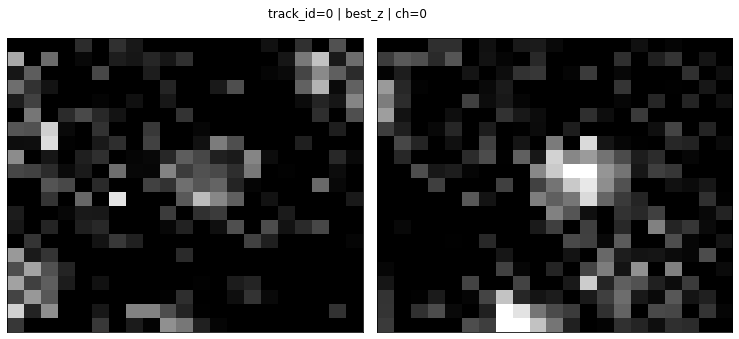

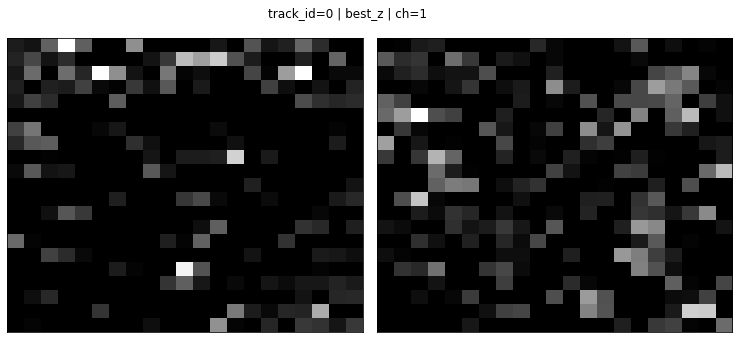

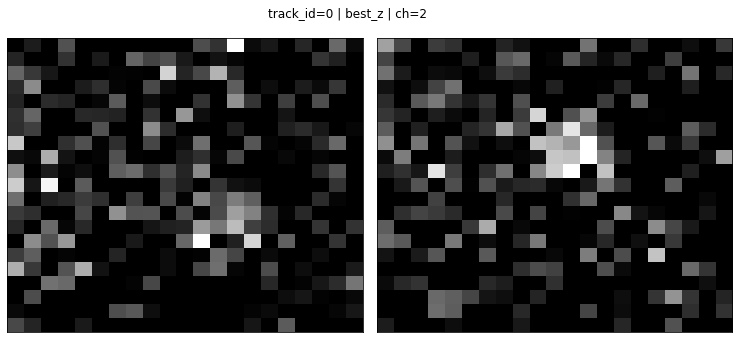

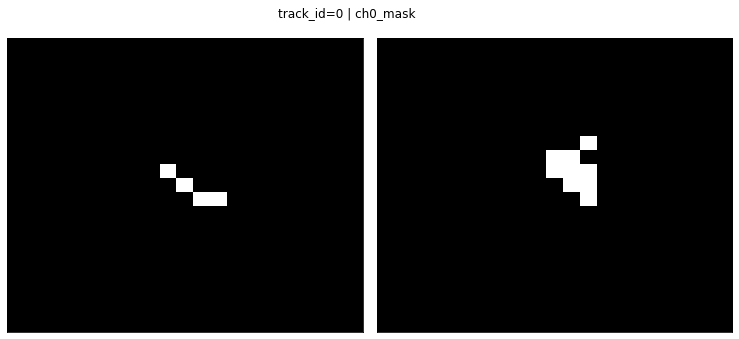

In [13]:
# Check masks, if desired (without napari)
my_ta.isel(rna=0, exp=0, fov=0).tplot.plot_trackarray_crops(track_ids=[0],t=(0,10,1),suppress_labels=True);
my_ta.isel(rna=0, exp=0, fov=0).tplot.plot_trackarray_crops(track_ids=[0],t=(0,10,1),suppress_labels=True,layer="ch0_mask");

In [14]:
# Check masks with napari
viewer, layers = my_ta.napari.montage_viewer(
    row="track_id",
    col="t",
    show=("best_z", "ch0_mask"),
    ch=0,
    #ch=[0, 1, 2],  # RGB
    colormaps={"ch0_mask": "magenta","best_z": "green"},
    image_contrast=[0.5,99.5],
    show_tile_text=False,  # adds layer w/ crop coords; takes memory,
)

In [15]:
# Make measurements of desired properties 
# See https://scikit-image.org/docs/stable/api/skimage.measure.html#skimage.measure.regionprops
my_ta.measure.mask_props(source ="ch0_mask", props=['eccentricity','major_axis_length_px','minor_axis_length_px']);

In [16]:
total = 0
for name, da in my_ta.ds.data_vars.items():
    mb = da.nbytes / 1024**2
    total += da.nbytes
    print(f"{name:20s} {str(da.shape):30s} {mb:10.1f} MB")

print(f"\nTOTAL: {total / 1024**2:.1f} MB")
print(f"TOTAL: {total / 1024**3:.2f} GB")

xc                   (2, 2, 10, 156, 2, 3)                 0.1 MB
yc                   (2, 2, 10, 156, 2, 3)                 0.1 MB
zc                   (2, 2, 10, 156, 2, 3)                 0.1 MB
xc_pix               (2, 2, 10, 156, 2, 3)                 0.1 MB
yc_pix               (2, 2, 10, 156, 2, 3)                 0.1 MB
zc_pix               (2, 2, 10, 156, 2, 3)                 0.1 MB
xc_pad               (2, 2, 10, 156, 2, 3)                 0.1 MB
yc_pad               (2, 2, 10, 156, 2, 3)                 0.1 MB
z_pos                (2, 2, 10, 156, 2, 3)                 0.1 MB
id                   (2, 2, 10, 156, 2)                    0.0 MB
track_id_orig        (2, 2, 10, 156)                       0.0 MB
z_pos_best           (2, 2, 10, 156, 2)                    0.0 MB
zc_best_pix          (2, 2, 10, 156, 2, 3)                 0.1 MB
zc_best              (2, 2, 10, 156, 2, 3)                 0.1 MB
best_z               (2, 2, 10, 3, 156, 2, 21, 21)       126.0 MB
signal    

In [17]:
# =======================================
# SAVE YOUR WORK TO A NEW CROP/TRACKARRAY
# =======================================
track_n_max=550 # Can be useful to save memory; random, but loss of some data
my_file = ca.io.save_croparray(my_ta.isel(track_id=slice(0, track_n_max)), output_dir=OUTPUT)
my_file

C:\Users\StasLab\Github\croparray\croparray\io.py:469: SerializationWarning: saving variable xc_pix with floating point data as an integer dtype without any _FillValue to use for NaNs
  ds_to_save.to_netcdf(str(out_path), **kwargs)
c:\Users\StasLab\anaconda3\envs\croparray_env\lib\site-packages\xarray\core\duck_array_ops.py:253: RuntimeWarning: invalid value encountered in cast
  return data.astype(dtype, **kwargs)
C:\Users\StasLab\Github\croparray\croparray\io.py:469: SerializationWarning: saving variable yc_pix with floating point data as an integer dtype without any _FillValue to use for NaNs
  ds_to_save.to_netcdf(str(out_path), **kwargs)
C:\Users\StasLab\Github\croparray\croparray\io.py:469: SerializationWarning: saving variable zc_pix with floating point data as an integer dtype without any _FillValue to use for NaNs
  ds_to_save.to_netcdf(str(out_path), **kwargs)
C:\Users\StasLab\Github\croparray\croparray\io.py:469: SerializationWarning: saving variable xc_pad with floating poi

WindowsPath('//129.82.125.64/TSnas2/SharedInternal/RiboJamProject/20260409_deltaZNF/Z_2T_-_Position_10_XY1775780241.ome__38rna_exp_fov.nc')

In [18]:
# check your saved data; note concatenation history is saved
temp = ca.tools.open_trackarray(my_file)
temp

TrackArray(tracks=156, t=2)

### Auto and/or manual filtering of saved trackarray

In [19]:
import croparray as ca
from pathlib import Path
%gui qt

In [20]:
# ============================
# USER-DEFINED PARAMETERS
# ============================

INPUT_FILE = Path('//129.82.125.64/TSnas2/SharedInternal/RiboJamProject/20260409_deltaZNF/Z_2T_-_Position_10_XY1775780241.ome__38rna_exp_fov.nc')

In [21]:
# Need to open this way to get proper doc strings:
from croparray.trackarray.object import TrackArray
my_ta: TrackArray = ca.io.open_trackarray(INPUT_FILE, as_object=True)

In [22]:
# Create a layer that automatically finds bad spots that have mask area bigger than 2x median and have a mask center of mask that is more than 4 pixels away from the signal center. This happens when the signal is very dim and the mask is basically random noise, which can cause bad measurements. This will create a new boolean layer called "auto_bad" that you can use to filter out these bad spots in your analysis. You can adjust the parameters as needed for your specific dataset.
my_ta.measure.auto_bad(source='ch0_mask', area_factor=2.0, max_dist_px=4, exclude_empty=False, out_name='bad', save_sidecar=True, output_dir=INPUT_FILE.parent);

[auto_bad] Saved sidecar: \\129.82.125.64\TSnas2\SharedInternal\RiboJamProject\20260409_deltaZNF\Z_2T_-_Position_10_XY1775780241.ome__38rna_exp_fov__manual__bad.nc


In [ ]:
# Quick and user-friendly manual filtering of tracks with napari 
# Create and save filter names (e.g. a 'bad' filter to remove noisy crops/tracks)
# Can also create filters like 'toi' to highlight tracks of interest  
filter_name = "bad" 
viewer, layers, ft = my_ta.napari.manual_filter_montage(
    row="track_id",                 
    col="t",  # can be 'track_id' or 't'
    filter_name=filter_name,
    show=("best_z", "ch0_mask"),
    ch=0,
    colormaps={"ch0_mask":"magenta", "best_z":"green", filter_name:"yellow"},
    output_dir= INPUT_FILE.parent,
    show_tile_text=False, # adds layer w/ crop coords; takes memory,
    show_click_info=True, # useful for debugging
)

INFO: Saved manual filter sidecar:
\\129.82.125.64\TSnas2\SharedInternal\RiboJamProject\20260409_deltaZNF\Z_2T_-_Position_10_XY1775780241.ome__38rna_exp_fov__manual__bad.nc
INFO: Saved manual filter sidecar:
\\129.82.125.64\TSnas2\SharedInternal\RiboJamProject\20260409_deltaZNF\Z_2T_-_Position_10_XY1775780241.ome__38rna_exp_fov__manual__bad.nc
INFO: Saved manual filter sidecar:
\\129.82.125.64\TSnas2\SharedInternal\RiboJamProject\20260409_deltaZNF\Z_2T_-_Position_10_XY1775780241.ome__38rna_exp_fov__manual__bad.nc
INFO: Saved manual filter sidecar:
\\129.82.125.64\TSnas2\SharedInternal\RiboJamProject\20260409_deltaZNF\Z_2T_-_Position_10_XY1775780241.ome__38rna_exp_fov__manual__bad.nc
INFO: Saved manual filter sidecar:
\\129.82.125.64\TSnas2\SharedInternal\RiboJamProject\20260409_deltaZNF\Z_2T_-_Position_10_XY1775780241.ome__38rna_exp_fov__manual__bad.nc
INFO: Saved manual filter sidecar:
\\129.82.125.64\TSnas2\SharedInternal\RiboJamProject\20260409_deltaZNF\Z_2T_-_Position_10_XY17757802

In [ ]:
# Test your filter:
my_ta.where(my_ta.ds[filter_name] == 0).napari.montage_viewer(row="track_id", col="t",show=("best_z","ch0_mask"),ch=0,show_tile_text=False)

(Viewer(camera=Camera(center=(0.0, np.float64(6982.0), np.float64(104.5)), zoom=np.float64(0.05442176870748299), angles=(0.0, 0.0, 90.0), perspective=0.0, mouse_pan=True, mouse_zoom=True, orientation=(<DepthAxisOrientation.TOWARDS: 'towards'>, <VerticalAxisOrientation.DOWN: 'down'>, <HorizontalAxisOrientation.RIGHT: 'right'>)), cursor=Cursor(position=(np.float64(0.0), np.float64(3.0), 0.0, 0.0), viewbox=None, scaled=True, style=<CursorStyle.STANDARD: 'standard'>, size=1.0), dims=Dims(ndim=4, ndisplay=2, order=(0, 1, 2, 3), axis_labels=('0', '1', '2', '3'), rollable=(True, True, True, True), range=(RangeTuple(start=np.float64(0.0), stop=np.float64(1.0), step=np.float64(1.0)), RangeTuple(start=np.float64(0.0), stop=np.float64(6.0), step=np.float64(1.0)), RangeTuple(start=np.float64(0.0), stop=np.float64(13964.0), step=np.float64(1.0)), RangeTuple(start=np.float64(0.0), stop=np.float64(209.0), step=np.float64(1.0))), margin_left=(0.0, 0.0, 0.0, 0.0), margin_right=(0.0, 0.0, 0.0, 0.0), poi